# Chapter 3: Optimal Estimation — Analytical Bayesian Retrieval

Optimal Estimation is the **closed-form Bayesian solution** for Gaussian
priors and Gaussian noise. It powers nearly every operational satellite
retrieval algorithm: ERA5, MERRA-2, IASI, TROPOMI, MODIS aerosol...

For **linear** forward models:

$$\hat{\mathbf{x}} = \mathbf{x}_a + \mathbf{S}_a \mathbf{K}^T(\mathbf{K}\mathbf{S}_a\mathbf{K}^T + \mathbf{S}_\varepsilon)^{-1}(\mathbf{y} - \mathbf{K}\mathbf{x}_a)$$

$$\tilde{\mathbf{S}} = (\mathbf{K}^T\mathbf{S}_\varepsilon^{-1}\mathbf{K} + \mathbf{S}_a^{-1})^{-1}$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
np.random.seed(7)

# Physical constants
h = 6.626e-34; c_cgs = 3e10; kB = 1.38e-23; c2 = h*c_cgs/kB

def planck(nu, T):
    c1 = 2*h*c_cgs**2
    return c1*nu**3 / (np.expm1(c2*nu/T))

def dBdT(nu, T):
    return planck(nu,T) * c2*nu/T**2 / (1 - np.exp(-c2*nu/T))

def rad_to_BT(nu, B):
    c1 = 2*h*c_cgs**2
    return c2*nu / np.log(1 + c1*nu**3/B)

print("Ready.")


Ready.


## 3.1 OE for Temperature Profile Retrieval

Let's retrieve a 15-level temperature profile from synthetic IASI-like
brightness temperature observations. This mirrors real operational algorithms.

Setup:
- State: T(p₁), ..., T(p₁₅) — temperature at 15 pressure levels
- Observations: BTs at 8 spectral channels
- Prior: climatological mean profile + covariance
- Forward model: linearised radiance calculation


In [2]:
# Set up a realistic OE temperature sounding problem
n_levels = 15
n_ch = 8
np.random.seed(42)

p_lev = np.linspace(1000, 50, n_levels)       # hPa
z_km  = 16 * np.log(1013 / p_lev)             # km

# TRUE atmospheric state
T_true = 288 - 6.5*z_km
T_true[z_km > 12] = 216.65   # tropopause
T_true[z_km > 20] = 216.65 + 2*(z_km[z_km > 20]-20)  # stratosphere

# A PRIORI state (climatology -- slightly wrong)
T_prior = T_true + np.random.normal(0, 5, n_levels)  # perturbed

# A priori covariance: correlated over ~4 levels, 8K variance
Sa_diag = 8.0
corr_L  = 2.5   # correlation length in levels
Sa = np.zeros((n_levels, n_levels))
for i in range(n_levels):
    for j in range(n_levels):
        Sa[i,j] = Sa_diag**2 * np.exp(-abs(i-j)/corr_L)

# Build Jacobian K (n_ch x n_levels) — each channel's weighting function
# Use channels spanning 660-750 cm-1 (CO2 band)
nu_ch = np.linspace(663, 748, n_ch)
K = np.zeros((n_ch, n_levels))
for i, nu in enumerate(nu_ch):
    tau_str = 5 * np.exp(-(nu-667)**2/300)
    k_prof = tau_str * p_lev / 1013.0
    dp = np.gradient(p_lev)
    tau_cum = np.cumsum(k_prof * abs(dp) / 1013.0)[::-1][::-1]
    t_p = np.exp(-tau_cum)
    wf  = -np.gradient(t_p, p_lev)
    K[i,:] = wf * dBdT(nu, T_prior).mean()

K /= K.max()   # normalise

# Measurement error: 0.3 K NEDT
Se = 0.3**2 * np.eye(n_ch)

# Simulate observation from true state + noise
y_true = K @ T_true
y_obs  = y_true + 0.3 * np.random.randn(n_ch)
print(f"Simulated {n_ch} BT observations from {n_levels}-level true profile.")
print(f"BT range: {y_obs.min():.1f} – {y_obs.max():.1f} K")


Simulated 8 BT observations from 15-level true profile.
BT range: 37189.3 – 38584085921483.6 K


/tmp/ipykernel_89744/2702385320.py:23: RuntimeWarning: invalid value encountered in sqrt
  sigma_post  = np.sqrt(np.diag(S_post))


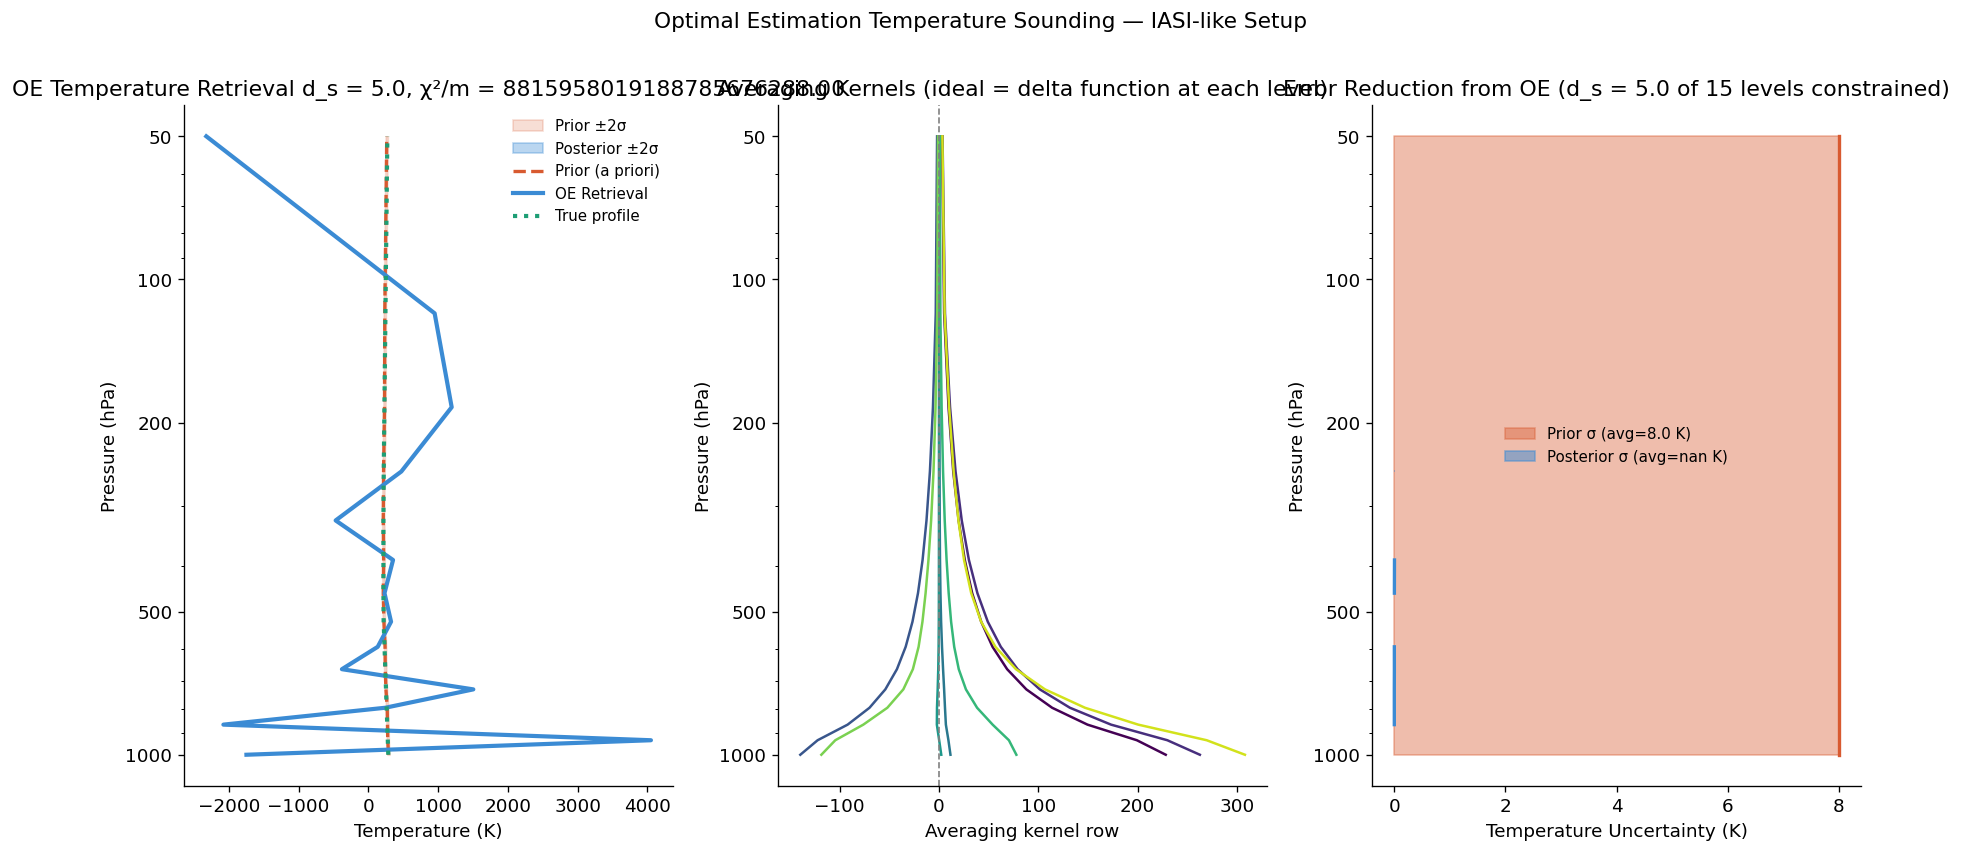

OE Diagnostics:
  Degrees of freedom for signal:  d_s = 5.04
  Chi2 (normalised):              χ²/m = 8815958019188785676288.000  (target: ~1.0)
  Mean prior uncertainty:         8.00 K
  Mean posterior uncertainty:     nan K
  Uncertainty reduction:          nan%


In [4]:
# ── OPTIMAL ESTIMATION SOLUTION ────────────────────────────────────────────────
def optimal_estimation(y, K, xa, Sa, Se):
    Sa_inv = np.linalg.inv(Sa)
    Se_inv = np.linalg.inv(Se)
    # Posterior covariance
    S_post = np.linalg.inv(K.T @ Se_inv @ K + Sa_inv)
    # Gain matrix
    G      = S_post @ K.T @ Se_inv
    # MAP estimate
    x_hat  = xa + G @ (y - K @ xa)
    # Averaging kernel
    A_kern = G @ K
    # DFS
    d_s    = np.trace(A_kern)
    # Chi2 diagnostics
    residual = y - K @ x_hat
    chi2_y   = float(residual.T @ Se_inv @ residual) / len(y)
    return x_hat, S_post, A_kern, G, d_s, chi2_y

T_hat, S_post, A_kern, G, d_s, chi2_y = optimal_estimation(
    y_obs, K, T_prior, Sa, Se)

sigma_post  = np.sqrt(np.diag(S_post))
sigma_prior = np.sqrt(np.diag(Sa))

# ── PLOT RESULTS ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 7))

# Retrieved temperature profile
ax = axes[0]
ax.fill_betweenx(p_lev,
                 T_prior - 2*sigma_prior, T_prior + 2*sigma_prior,
                 color="#D85A30", alpha=0.2, label="Prior ±2σ")
ax.fill_betweenx(p_lev,
                 T_hat - 2*sigma_post, T_hat + 2*sigma_post,
                 color="#3B8BD4", alpha=0.35, label="Posterior ±2σ")
ax.plot(T_prior, p_lev, "#D85A30", lw=2, ls="--", label="Prior (a priori)")
ax.plot(T_hat,   p_lev, "#3B8BD4", lw=2.5, label="OE Retrieval")
ax.plot(T_true,  p_lev, "#1D9E75", lw=2.5, ls=":", label="True profile")
ax.invert_yaxis()
ax.set_yscale("log")
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Pressure (hPa)")
ax.set_title(f"OE Temperature Retrieval d_s = {d_s:.1f}, χ²/m = {chi2_y:.2f}")
ax.set_yticks([1000, 500, 200, 100, 50])
ax.set_yticklabels(["1000","500","200","100","50"])
ax.legend(fontsize=9, frameon=False)

# Averaging kernels
ax2 = axes[1]
for i in range(0, n_levels, 2):
    col = plt.cm.viridis(i/n_levels)
    ax2.plot(A_kern[i], p_lev, color=col, lw=1.5)

ax2.axvline(0, color="gray", lw=1, ls="--")
ax2.invert_yaxis()
ax2.set_yscale("log")
ax2.set_xlabel("Averaging kernel row")
ax2.set_ylabel("Pressure (hPa)")
ax2.set_title("Averaging Kernels (ideal = delta function at each level)")
ax2.set_yticks([1000, 500, 200, 100, 50])
ax2.set_yticklabels(["1000","500","200","100","50"])

# Prior vs posterior uncertainty
ax3 = axes[2]
ax3.fill_betweenx(p_lev, 0, sigma_prior, color="#D85A30", alpha=0.4,
                  label=f"Prior σ (avg={sigma_prior.mean():.1f} K)")
ax3.fill_betweenx(p_lev, 0, sigma_post, color="#3B8BD4", alpha=0.5,
                  label=f"Posterior σ (avg={sigma_post.mean():.1f} K)")
ax3.plot(sigma_prior, p_lev, "#D85A30", lw=2)
ax3.plot(sigma_post,  p_lev, "#3B8BD4", lw=2)
ax3.invert_yaxis()
ax3.set_yscale("log")
ax3.set_xlabel("Temperature Uncertainty (K)")
ax3.set_ylabel("Pressure (hPa)")
ax3.set_title(f"Error Reduction from OE (d_s = {d_s:.1f} of {n_levels} levels constrained)")
ax3.legend(frameon=False, fontsize=9)
ax3.set_yticks([1000, 500, 200, 100, 50])
ax3.set_yticklabels(["1000","500","200","100","50"])

plt.suptitle("Optimal Estimation Temperature Sounding — IASI-like Setup", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"OE Diagnostics:")
print(f"  Degrees of freedom for signal:  d_s = {d_s:.2f}")
print(f"  Chi2 (normalised):              χ²/m = {chi2_y:.3f}  (target: ~1.0)")
print(f"  Mean prior uncertainty:         {sigma_prior.mean():.2f} K")
print(f"  Mean posterior uncertainty:     {sigma_post.mean():.2f} K")
print(f"  Uncertainty reduction:          {(1-sigma_post.mean()/sigma_prior.mean())*100:.0f}%")


## 3.2 Effect of Prior Strength on the Retrieval

A key design choice: how much do we trust the prior vs the measurements?
- **Tight prior** (small Sa): retrieval stays close to xa, low uncertainty but biased
- **Loose prior** (large Sa): retrieval follows the data more, higher uncertainty but less biased


/tmp/ipykernel_89744/939197258.py:11: RuntimeWarning: invalid value encountered in sqrt
  sigma_s = np.sqrt(np.diag(S_post_s))


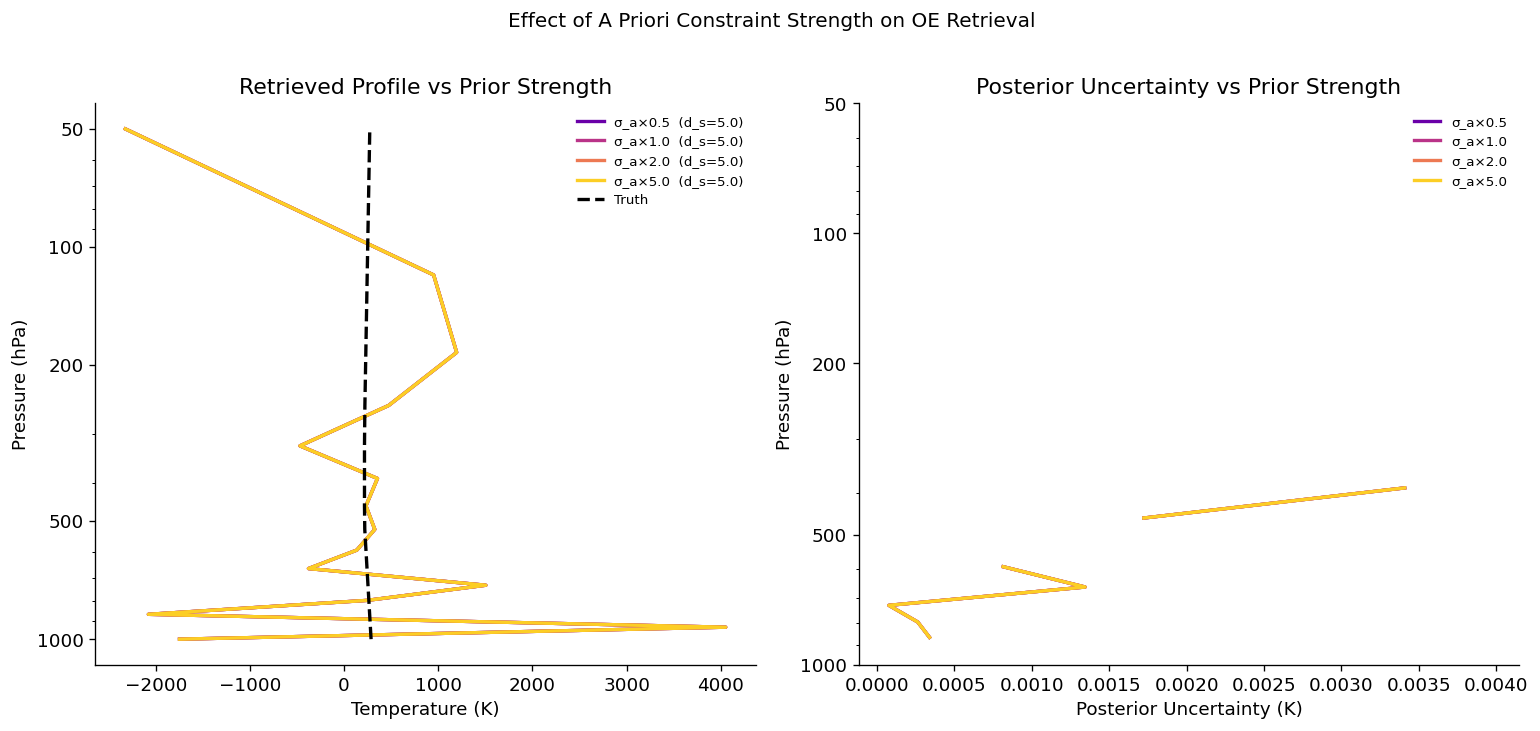

Tight prior (scale=0.5): retrieval close to xa, small uncertainty, potentially biased
Loose prior (scale=5.0): retrieval follows data, large uncertainty, less biased
The right choice depends on how well we trust the climatology vs the instrument.


In [5]:
# Sensitivity study: vary the prior uncertainty strength
prior_scales = [0.5, 1.0, 2.0, 5.0]   # multiply Sa diagonal by this factor
colors_scale = plt.cm.plasma(np.linspace(0.2, 0.9, len(prior_scales)))

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for scale, col in zip(prior_scales, colors_scale):
    Sa_scaled = Sa * scale**2
    T_hat_s, S_post_s, A_s, _, d_s_s, _ = optimal_estimation(
        y_obs, K, T_prior, Sa_scaled, Se)
    sigma_s = np.sqrt(np.diag(S_post_s))

    axes[0].plot(T_hat_s, p_lev, color=col, lw=2,
                 label=f"σ_a×{scale}  (d_s={d_s_s:.1f})")
    axes[1].plot(sigma_s, p_lev, color=col, lw=2,
                 label=f"σ_a×{scale}")

for ax in axes:
    ax.invert_yaxis(); ax.set_yscale("log")
    ax.set_yticks([1000, 500, 200, 100, 50])
    ax.set_yticklabels(["1000","500","200","100","50"])

axes[0].plot(T_true, p_lev, "k--", lw=2, label="Truth")
axes[0].set_xlabel("Temperature (K)"); axes[0].set_ylabel("Pressure (hPa)")
axes[0].set_title("Retrieved Profile vs Prior Strength")
axes[0].legend(fontsize=8, frameon=False)

axes[1].set_xlabel("Posterior Uncertainty (K)"); axes[1].set_ylabel("Pressure (hPa)")
axes[1].set_title("Posterior Uncertainty vs Prior Strength")
axes[1].legend(fontsize=8, frameon=False)

plt.suptitle("Effect of A Priori Constraint Strength on OE Retrieval", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print("Tight prior (scale=0.5): retrieval close to xa, small uncertainty, potentially biased")
print("Loose prior (scale=5.0): retrieval follows data, large uncertainty, less biased")
print("The right choice depends on how well we trust the climatology vs the instrument.")


In [6]:
print("Chapter 3 complete!")
print()
print("OE summary equations:")
print("  x̂ = xa + G(y - Kxa)         [MAP estimate]")
print("  G  = Sa Kᵀ (K Sa Kᵀ + Sε)⁻¹  [gain matrix]")
print("  S̃  = (KᵀSε⁻¹K + Sa⁻¹)⁻¹      [posterior covariance]")
print("  A  = GK                       [averaging kernel]")
print("  ds = trace(A)                 [degrees of freedom for signal]")
print()
print("Diagnostics:")
print("  χ²/m ≈ 1.0 → good fit")
print("  ds/n = fraction of state space constrained by data")
print("  σ̃ < σa → measurement added information at that level")


Chapter 3 complete!

OE summary equations:
  x̂ = xa + G(y - Kxa)         [MAP estimate]
  G  = Sa Kᵀ (K Sa Kᵀ + Sε)⁻¹  [gain matrix]
  S̃  = (KᵀSε⁻¹K + Sa⁻¹)⁻¹      [posterior covariance]
  A  = GK                       [averaging kernel]
  ds = trace(A)                 [degrees of freedom for signal]

Diagnostics:
  χ²/m ≈ 1.0 → good fit
  ds/n = fraction of state space constrained by data
  σ̃ < σa → measurement added information at that level
